In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
import yfinance as yf
rets = yf.download(tickers=['SPY', 'BND'], interval='1mo', start='2015-10-01', auto_adjust='False')["Close"]
rets


[*********************100%***********************]  2 of 2 completed


Ticker,BND,SPY
Date,,
2015-10-01,61.341080,175.703690
2015-11-01,61.095867,176.345917
2015-12-01,60.815720,172.272919
2016-01-01,61.848534,164.670288
2016-02-01,62.242062,164.534332
...,...,...
2025-06-01,72.439430,614.325623
2025-07-01,72.254677,630.332458
2025-08-01,73.080185,643.266602


In [32]:
rets.dropna(inplace=True)
rets


Ticker,BND,SPY
Date,,
2015-10-01,61.341080,175.703690
2015-11-01,61.095867,176.345917
2015-12-01,60.815720,172.272919
2016-01-01,61.848534,164.670288
2016-02-01,62.242062,164.534332
...,...,...
2025-06-01,72.439430,614.325623
2025-07-01,72.254677,630.332458
2025-08-01,73.080185,643.266602


In [33]:
rets=rets.to_period('M')
rets

Ticker,BND,SPY
Date,,
2015-10,61.341080,175.703690
2015-11,61.095867,176.345917
2015-12,60.815720,172.272919
2016-01,61.848534,164.670288
2016-02,62.242062,164.534332
...,...,...
2025-06,72.439430,614.325623
2025-07,72.254677,630.332458
2025-08,73.080185,643.266602


<Axes: xlabel='Date'>

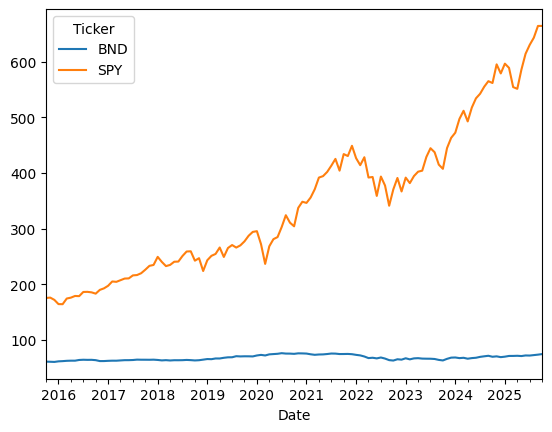

In [36]:
rets.plot()

<Axes: xlabel='Date'>

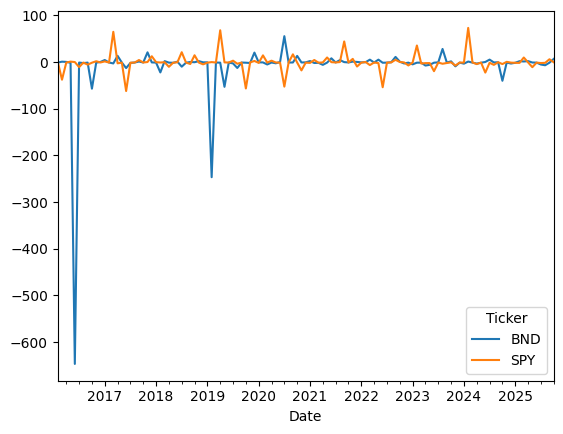

In [42]:
rets=rets.pct_change().dropna()
rets
rets.plot()

In [45]:
compound_returns = (rets+1).prod() - 1
(compound_returns * 100).round(2).astype('str') + '%'

Ticker
BND    -76.49%
SPY     137.7%
dtype: object

In [ ]:
rets.head(2)
rets.tail(4)
rets.size #234
rets.shape #(117,2)
rets.index #PeriodIndex(['2016-02', '2016-03', ...'2025-10'],dtype='period[M]', name='Date', length=117)
rets.columns #Index(['BND', 'SPY'], dtype='object', name='Ticker')

Index(['BND', 'SPY'], dtype='object', name='Ticker')

In [ ]:
rets['SPY'] # Series

Date
2016-02     0.847581
2016-03   -37.720050
2016-04    -1.012961
2016-05     1.038179
2016-06     0.127401
             ...    
2025-06    -1.079446
2025-07    -2.006828
2025-08    -1.545313
2025-09     6.069449
2025-10    -0.297887
Freq: M, Name: SPY, Length: 117, dtype: float64

In [ ]:
rets[['SPY']] # Dataframe

Ticker,SPY
Date,
2016-02,0.847581
2016-03,-37.720050
2016-04,-1.012961
2016-05,1.038179
2016-06,0.127401
...,...
2025-06,-1.079446
2025-07,-2.006828
2025-08,-1.545313


In [65]:
rets.loc['2020-12']

Ticker
BND   -0.610295
SPY   -1.076550
Name: 2020-12, dtype: float64

In [ ]:
rets.iloc[20] # 20 is index position

In [66]:
rets.loc['2020-12':'2021-05']

Ticker,BND,SPY
Date,,
2020-12,-0.610295,-1.076550
2021-01,2.239641,-1.778442
2021-02,-1.910597,4.479516
2021-03,-1.565312,-1.288264
2021-04,-5.914224,-0.698371
2021-05,-1.106580,9.890126


In [ ]:
rets.std # standard deviation

<bound method DataFrame.std of Ticker          BND        SPY
Date                          
2016-02   -0.973715   0.847581
2016-03    0.905112 -37.720050
2016-04    0.436303  -1.012961
2016-05   -1.324068   1.038179
2016-06 -646.925839   0.127401
...             ...        ...
2025-06   -1.113332  -1.079446
2025-07   -5.204001  -2.006828
2025-08   -6.753310  -1.545313
2025-09   -1.269685   6.069449
2025-10    6.799242  -0.297887

[117 rows x 2 columns]>

In [70]:
n_periods = rets.shape[0]
compounded_growth = (1+rets).prod()
monthly_ret = compounded_growth**(1/n_periods) - 1
(monthly_ret + 1)**12 - 1

Ticker
BND   -0.137994
SPY    0.092866
dtype: float64

In [71]:
def annualize_rets(r, periods_per_year=12):
    compounded_growth = (1+r).prod()
    n_periods = r.shape[0]
    return compounded_growth**(periods_per_year / n_periods) - 1

annualize_rets(rets)

Ticker
BND   -0.137994
SPY    0.092866
dtype: float64

In [72]:
def annualize_vol(r, periods_per_year=12):
    return r.std() * (periods_per_year**0.5)

annualize_vol(rets)

Ticker
BND    224.037674
SPY     60.396796
dtype: float64

In [73]:
# Raw Sharpe Ratio
annualize_rets(rets) / annualize_vol(rets)

Ticker
BND   -0.000616
SPY    0.001538
dtype: float64

<Axes: xlabel='Date'>

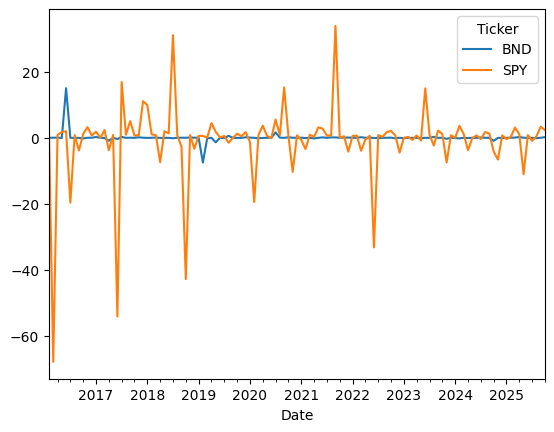

In [75]:
wealth_index = (rets+1).cumprod()
wealth_index.plot()